In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
import sys
import tifffile as tf
import torch

sys.path.append("../")
sys.path.append("../neurotrack")
from data_prep import draw, generate, image, load, save
from data import neuron_data

# Quantify real neuron image and skeleton characteristics to aid in image simulation

## Load source data

In [3]:
image_dir = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset")
image_paths = list(image_dir.glob("*_image.tif"))
swc_dir = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset")
swc_paths = list(swc_dir.glob("*.swc"))

# place swc_paths in the same order as image_paths
swc_paths_reordered = []
for path in image_paths:
    stem = path.stem
    matching_swc = [p for p in swc_paths if p.stem == stem.split("_image")[0]]
    if not matching_swc:
        print(f"no matching swc for file name: {stem}")
        break
    swc_paths_reordered.append(matching_swc[0])

swc_paths = swc_paths_reordered

## First, get foreground mean and variance

In [ ]:
swc_list = load.swc(swc_paths[0])
fg_mask_data = draw.neuron_from_swc(swc_list, width=4.0, binary=True, noise=0.0)
fg_mask = fg_mask_data["image"][0]

plt.figure(figsize=(10, 10))
plt.imshow(fg_mask.amax(0))
plt.show()

loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/100108c3.swc


AttributeError: module 'data_prep.draw' has no attribute 'neuron_from_swc'

In [123]:
means = []
sigmas = []
for image_path, swc_path in zip(image_paths, swc_paths):
    # load image
    print(f"Loading image {image_path}")
    img = tf.imread(image_path)
    shape = img.shape

    # load swc
    swc_list = load.swc(swc_path)
    fg_mask_data = draw.neuron_from_swc(swc_list, width=4.0, shape=shape, binary=True, noise=0.0)
    fg_mask = fg_mask_data["image"][0]

    fg = torch.from_numpy(img) * fg_mask
    means.append(fg[fg > 0].mean())
    sigmas.append(fg[fg > 0].std())

Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/100108c3_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/100108c3.swc
Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby.swc
Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/091201c1_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091201c1.swc
Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/1_CL-I_X_OREGON_R_ddaE_membrane-GFP_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-I_X_OREGON_R_ddaE_membrane-GFP.swc
Lo

/home/brysongray/neurotrack/notebooks/../data_prep/image.py:258: UserWarning: Center [ 30.69139966 157.60485    142.1108    ] is out of bounds for image shape torch.Size([31, 614, 633]). Translating to the nearest valid index.
  warnings.warn(f"Center {center} is out of bounds for image shape {shape}. Translating to the nearest valid index.")
/home/brysongray/neurotrack/notebooks/../data_prep/image.py:258: UserWarning: Center tensor([ 30.6914, 157.6049, 142.1108], dtype=torch.float64) is out of bounds for image shape torch.Size([31, 614, 633]). Translating to the nearest valid index.
  warnings.warn(f"Center {center} is out of bounds for image shape {shape}. Translating to the nearest valid index.")


Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/110203c3_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/110203c3.swc


/home/brysongray/neurotrack/notebooks/../data_prep/image.py:258: UserWarning: Center [ 82.39228 818.56    263.51444] is out of bounds for image shape torch.Size([93, 819, 819]). Translating to the nearest valid index.
  warnings.warn(f"Center {center} is out of bounds for image shape {shape}. Translating to the nearest valid index.")
/home/brysongray/neurotrack/notebooks/../data_prep/image.py:258: UserWarning: Center [ 81.87148 818.732   263.34284] is out of bounds for image shape torch.Size([93, 819, 819]). Translating to the nearest valid index.
  warnings.warn(f"Center {center} is out of bounds for image shape {shape}. Translating to the nearest valid index.")
/home/brysongray/neurotrack/notebooks/../data_prep/image.py:258: UserWarning: Center [ 81.34708 818.74    263.14644] is out of bounds for image shape torch.Size([93, 819, 819]). Translating to the nearest valid index.
  warnings.warn(f"Center {center} is out of bounds for image shape {shape}. Translating to the nearest valid i

Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/140921c9_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140921c9.swc
Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/140918c8_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140918c8.swc
Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/140921c14_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140921c14.swc
Loading image /home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset/2_CL-I_Membrane-GFP_X_F-Actin-Red_ddaD_Membrane-GFP_F-Actin-Red_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/2_CL-I_Membrane-GFP_X_F-Actin-Red_ddaD_Membrane-GFP_F-Actin-Red.swc
Loading image /home/brysongray/data/neurotra

In [122]:
print("Foreground means:    Foreground sigmas:")
for m, s in zip(means, sigmas):
    print(f" {float(m.item()/255):.5f} ------------ {float(s.item()/255):.5f}")
print("Total mean and sigma:")
print(f" {float(np.array(means).mean().item()/255):.5f} ------------ {float(np.array(sigmas).mean().item()/255):.5f}")

Foreground means:    Foreground sigmas:
 0.13918 ------------ 0.18147
 0.25036 ------------ 0.22796
 0.16610 ------------ 0.21306
 0.55999 ------------ 0.33777
 0.21050 ------------ 0.22692
 0.15949 ------------ 0.22323
 0.40608 ------------ 0.33698
 0.21648 ------------ 0.22364
 0.22586 ------------ 0.22529
 0.29128 ------------ 0.23567
 0.41447 ------------ 0.34403
 0.17007 ------------ 0.21741
 0.11141 ------------ 0.14546
 0.20148 ------------ 0.21722
 0.49237 ------------ 0.32996
 0.10250 ------------ 0.15812
 0.24216 ------------ 0.25327
 0.21963 ------------ 0.24205
 0.21865 ------------ 0.24648
 0.47977 ------------ 0.33762
 0.12224 ------------ 0.14657
 0.31347 ------------ 0.29176
 0.24606 ------------ 0.25803
 0.17631 ------------ 0.19959
 0.18123 ------------ 0.21147
 0.21708 ------------ 0.24095
 0.21608 ------------ 0.24553
 0.19332 ------------ 0.22037
 0.16880 ------------ 0.22226
 0.28401 ------------ 0.22120
Total mean and sigma:
 0.24655 ------------ 0.23938


# Get background mean and variance

In [109]:
bg_means = []
bg_sigmas = []

for swc_path, image_path in zip(swc_paths, image_paths):
    print(f"Processing background for {image_path.name}")
    swc_list = load.swc(swc_path)
    img = tf.imread(image_path)
    
    swc_points = np.array(swc_list)[:, 4:1:-1]  # z, y, x format
    
    # Sample points to avoid memory issues (same approach as previous cell)
    stride = 16
    z_sample = np.arange(0, img.shape[0], stride)
    y_sample = np.arange(0, img.shape[1], stride)
    x_sample = np.arange(0, img.shape[2], stride)
    
    z_coords, y_coords, x_coords = np.meshgrid(z_sample, y_sample, x_sample, indexing='ij')
    sampled_coords = np.stack([z_coords.flatten(), y_coords.flatten(), x_coords.flatten()], axis=1)
    
    # Calculate distances from each sampled point to all SWC nodes
    min_distances = []
    for coord in sampled_coords:
        distances = np.linalg.norm(swc_points - coord, axis=1)
        min_distances.append(np.min(distances))
    
    min_distances = np.array(min_distances)
    
    # Create mask for background points (far from neuron)
    background_threshold = 50.0  # pixels
    bg_mask = min_distances > background_threshold
    bg_coords = sampled_coords[bg_mask]
    
    if len(bg_coords) > 0:
        # Extract intensities from background regions
        bg_intensities = []
        for coord in bg_coords:
            z, y, x = int(coord[0]), int(coord[1]), int(coord[2])
            bg_intensities.append(img[z, y, x])
        
        bg_intensities = np.array(bg_intensities)
        bg_means.append(bg_intensities.mean())
        bg_sigmas.append(bg_intensities.std())
        
        print(f"Background mean: {bg_means[-1]/255:.3f}, std: {bg_sigmas[-1]/255:.3f}")
    else:
        print("No background points found, using default values")


Processing background for 100108c3_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/100108c3.swc
Background mean: 0.005, std: 0.003
Processing background for 1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby.swc
Background mean: 0.013, std: 0.016
Processing background for 091201c1_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091201c1.swc
Background mean: 0.006, std: 0.004
Processing background for 1_CL-I_X_OREGON_R_ddaE_membrane-GFP_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-I_X_OREGON_R_ddaE_membrane-GFP.swc
Background mean: 0.020, std: 0.017
Processing background for 140918c7_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_p

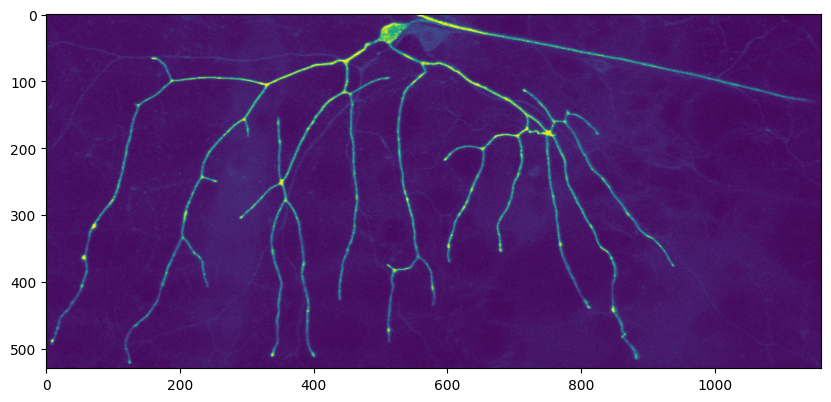

In [111]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(img.max(0))
plt.show()

In [121]:
print("Background means:    Background sigmas:")
for m, s in zip(bg_means, bg_sigmas):
    print(f" {float(m/255):.5f} ------------ {float(s/255):.5f}")

print("Total mean and sigma:")
print(f" {float(np.array(bg_means).mean()/255):.5f} ------------ {float(np.array(bg_sigmas).mean()/255):.5f}")

Background means:    Background sigmas:
 0.00528 ------------ 0.00281
 0.01295 ------------ 0.01589
 0.00559 ------------ 0.00356
 0.01993 ------------ 0.01715
 0.00335 ------------ 0.01670
 0.00229 ------------ 0.00393
 0.01907 ------------ 0.01528
 0.00462 ------------ 0.00398
 0.00339 ------------ 0.00180
 0.01068 ------------ 0.01933
 0.01372 ------------ 0.02702
 0.00568 ------------ 0.00570
 0.00911 ------------ 0.00452
 0.00565 ------------ 0.03493
 0.01744 ------------ 0.03410
 0.00529 ------------ 0.01698
 0.00349 ------------ 0.00494
 0.00605 ------------ 0.03767
 0.00324 ------------ 0.00177
 0.02296 ------------ 0.02185
 0.02063 ------------ 0.00548
 0.01714 ------------ 0.02758
 0.00225 ------------ 0.00642
 0.00397 ------------ 0.00100
 0.00314 ------------ 0.01541
 0.00411 ------------ 0.01214
 0.00427 ------------ 0.00980
 0.00393 ------------ 0.00683
 0.00291 ------------ 0.00607
 0.01930 ------------ 0.01613
Total mean and sigma:
 0.00872 ------------ 0.01323


## Measure the correlation in intensity from one node to the next

### $\rho = \frac{\sigma_{XY}}{\sigma_X\sigma_Y}$

In [4]:
swc_list = load.swc(swc_paths[0])
sections, section_graph = load.parse_swc(swc_list)

loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/100108c3.swc


In [98]:
correlations = []
first_and_last_intensities = []

for image_path, swc_path in zip(image_paths, swc_paths):
    print(f"Processing correlation for {image_path.name}")
    
    # Load image and swc
    img = tf.imread(image_path)
    swc_list = load.swc(swc_path)
    sections, section_graph = load.parse_swc(swc_list)
    
    # Extract coordinates and intensities for consecutive node pairs
    intensities_1 = []
    intensities_2 = []
    
    # also store the seed point intensity and intensity of the node farthest from the seed point.
    first_section_id = np.array(list(sections.keys())).min()
    seed_point = sections[first_section_id][0][0]  # first node of the first section
    seed_intensity = img[int(seed_point[0]), int(seed_point[1]), int(seed_point[2])]
    all_points = np.array(swc_list)[:, 4:1:-1]
    seed_point = sections[first_section_id][0][0]  # first node of the first section
    distances = np.linalg.norm(all_points - seed_point[None, :3], axis=1)
    farthest_idx = np.argmax(distances)
    farthest_point = all_points[farthest_idx]
    farthest_intensity = img[int(farthest_point[0]), int(farthest_point[1]), int(farthest_point[2])]

    first_and_last_intensities.append((float(seed_intensity), float(farthest_intensity)))

    for section in sections.values():
        for i in range(len(section) - 1):
            # Get coordinates for consecutive nodes
            node1 = section[i][0]
            node2 = section[i][1]

            # Extract x, y, z coordinates (indices 2, 3, 4 in swc format)
            z1, y1, x1 = int(node1[0]), int(node1[1]), int(node1[2])
            z2, y2, x2 = int(node2[0]), int(node2[1]), int(node2[2])

            # Ensure coordinates are within img bounds
            if (0 <= z1 < img.shape[0] and 0 <= y1 < img.shape[1] and 0 <= x1 < img.shape[2] and
                0 <= z2 < img.shape[0] and 0 <= y2 < img.shape[1] and 0 <= x2 < img.shape[2]):
                
                intensities_1.append(img[z1, y1, x1])
                intensities_2.append(img[z2, y2, x2])
    
    # Convert to tensors and compute correlation
    if len(intensities_1) > 1:
        int1 = torch.tensor(intensities_1, dtype=torch.float32)
        int2 = torch.tensor(intensities_2, dtype=torch.float32)
        
        correlation = torch.corrcoef(torch.stack([int1, int2]))[0, 1]
        correlations.append(correlation.item())
    else:
        correlations.append(0.0)

Processing correlation for 100108c3_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/100108c3.swc
Processing correlation for 1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-III_X_LifeActRuby_vpda_membrane-GFP_actin-LifeActRuby.swc
Processing correlation for 091201c1_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/091201c1.swc
Processing correlation for 1_CL-I_X_OREGON_R_ddaE_membrane-GFP_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/1_CL-I_X_OREGON_R_ddaE_membrane-GFP.swc
Processing correlation for 140918c7_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/140918c7.swc
Processing correlation for 140921c5_image.tif
loading file: /home/brysongray/data/neurotrack_data/gold166/

In [99]:
correlations

[0.9244911670684814,
 0.7100751399993896,
 0.8858342170715332,
 0.5646631717681885,
 0.6903395652770996,
 0.7974739670753479,
 0.4301927089691162,
 0.70820152759552,
 0.8415035605430603,
 0.8912345767021179,
 0.8098973631858826,
 0.7943042516708374,
 0.8830315470695496,
 0.7698906064033508,
 0.5198789834976196,
 0.8910305500030518,
 0.728852391242981,
 0.7450653314590454,
 0.7220253944396973,
 0.5283270478248596,
 0.9600377082824707,
 0.5720102787017822,
 0.748495876789093,
 0.7760705947875977,
 0.7632095217704773,
 0.8056493401527405,
 0.8460460901260376,
 0.7811156511306763,
 0.8106411695480347,
 0.5482428669929504]

In [100]:
first_and_last_intensities

[(251.0, 10.0),
 (254.0, 100.0),
 (255.0, 31.0),
 (255.0, 57.0),
 (255.0, 21.0),
 (255.0, 9.0),
 (255.0, 8.0),
 (255.0, 22.0),
 (254.0, 8.0),
 (255.0, 10.0),
 (13.0, 15.0),
 (24.0, 35.0),
 (255.0, 7.0),
 (255.0, 22.0),
 (255.0, 8.0),
 (168.0, 8.0),
 (255.0, 39.0),
 (255.0, 72.0),
 (255.0, 40.0),
 (255.0, 17.0),
 (126.0, 28.0),
 (215.0, 7.0),
 (255.0, 142.0),
 (255.0, 9.0),
 (255.0, 7.0),
 (255.0, 10.0),
 (255.0, 1.0),
 (255.0, 9.0),
 (255.0, 12.0),
 (8.0, 45.0)]

loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/100108c3.swc


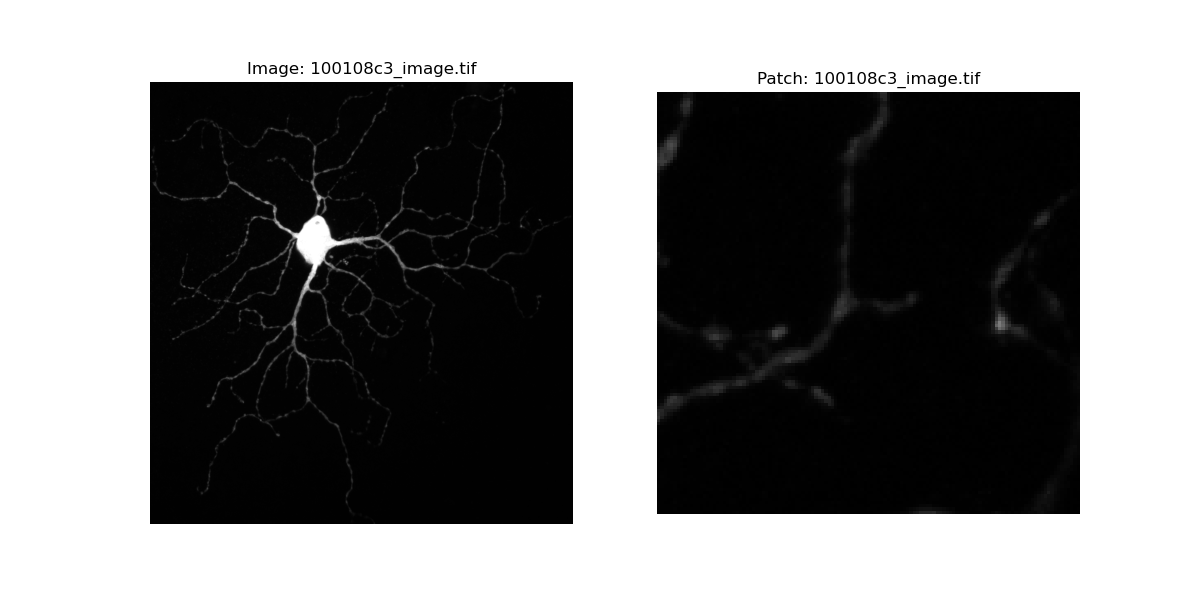

In [4]:
# load an image
idx = 0
img = tf.imread(image_paths[idx])
img = img.astype(np.float32) / 255.0
# load swc
swc_list = load.swc(swc_paths[idx])

img = image.Image(img[None])

# crop a patch from the image around a random point in the swc
random_node = np.random.choice(len(swc_list))
point = swc_list[random_node][2:5][::-1]
point = torch.tensor(point)
patch_size = 64
real_patch, padding = img.crop(point, patch_size)

# plot the image max projection
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img.data[0].amax(0), cmap="gray", vmax=1.0)
ax[0].set_title(f"Image: {image_paths[idx].name}")
ax[0].axis("off")

# plot the patch
ax[1].imshow(real_patch[0].amax(0), cmap="gray", vmax=1.0)
ax[1].set_title(f"Patch: {image_paths[idx].name}")
ax[1].axis("off")

plt.show()


In [23]:
# draw the swc with artifacts for comparison
sections, graph = load.parse_swc(swc_list)
branches, terminals = load.get_critical_points(swc_list, sections)
scale = 1.0

shape = img.data.shape[1:]
renderer = draw.NeuronRenderer(rng=np.random.default_rng(42))
config = draw.DrawingConfig(
    width=4.0,
    width_correlation=True,
    width_correlation_rho=0.90,
    segment_intensity_correlation=False,
    segment_intensity_correlation_rho=0.5,
    rgb=False,
    foreground_mean=1.0,
    foreground_std=0.0,
    background_mean=0.009,
    background_std=0.013,
    spatial_noise_scale=3.0,
    spatial_noise_amplitude=1.0,
    vignette_magnitude=0.0,
    blur=1.0
)
simulated_neuron = renderer.draw_neuron(sections, shape=shape, config=config)

    # foreground_mean=0.25,
    # foreground_std=0.239,
    # background_mean=0.009,
    # background_std=0.013,
    # simplex_scale=8.0,
    # simplex_amplitude=1.0,

In [74]:
complexity_config = neuron_data.DrawingComplexityConfig()
config = complexity_config.interpolate_config(complexity=0.0)
simulated_neuron = renderer.draw_neuron(sections, shape=shape, config=config)

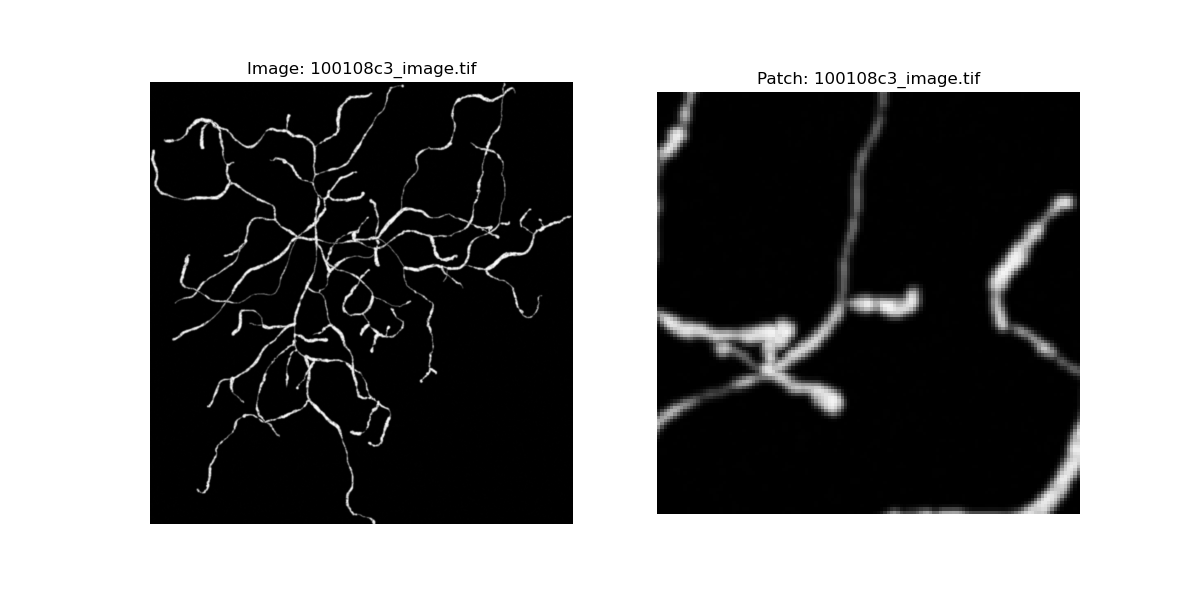

In [24]:
radius = 64
synthetic_patch, padding = simulated_neuron.crop(point, radius)

# plot the image max projection
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(simulated_neuron.data[0].amax(0), cmap="gray", vmax=1.0)
ax[0].set_title(f"Image: {image_paths[idx].name}")
ax[0].axis("off")

# plot the patch
ax[1].imshow(synthetic_patch[0].amax(0), cmap="gray", vmax=1.0)
# ax[1].imshow(real_patch[0].amax(0), cmap="Reds",  alpha=0.5) #,vmax=255)
ax[1].set_title(f"Patch: {image_paths[idx].name}")
ax[1].axis("off")

# Plot the neuron skeleton nodes over the simulated neuron image
swc_array = np.array(swc_list)
nodes_3d = swc_array[:, 2:5] # x, y, z coordinates

# Project nodes to 2D by taking max projection coordinates
nodes_2d = nodes_3d[:, :2]  # x, y coordinates for plotting

# Overlay skeleton nodes on both images
# ax[0].scatter(nodes_2d[:, 0], nodes_2d[:, 1], c='red', s=1, alpha=0.7, label='Skeleton nodes')
# Get subplot nodes.
# Filter nodes to only those within the patch boundaries
patch_x_min = point[2].item() - radius
patch_x_max = point[2].item() + radius
patch_y_min = point[1].item() - radius
patch_y_max = point[1].item() + radius

# Create mask for nodes within patch bounds
node_mask = ((nodes_2d[:, 0] >= patch_x_min) & 
             (nodes_2d[:, 0] < patch_x_max) & 
             (nodes_2d[:, 1] >= patch_y_min) & 
             (nodes_2d[:, 1] < patch_y_max))

patch_nodes = nodes_2d[node_mask]

# Adjust the coordinates of patch_nodes to be relative to the patch
# Adjust coordinates relative to patch origin (already implemented above)

if len(patch_nodes) > 0:
    # Adjust coordinates relative to patch origin
    patch_nodes_relative = patch_nodes.copy()
    patch_nodes_relative[:, 0] -= (patch_x_min - 0.5)
    patch_nodes_relative[:, 1] -= (patch_y_min - 0.5)
    
    # ax[1].scatter(patch_nodes_relative[:, 0], 
    #              patch_nodes_relative[:, 1], 
    #              c='red', s=1, alpha=0.7, label='Skeleton nodes')

# ax[0].legend()
# ax[1].legend()

plt.show()

torch.Size([128, 128, 128])


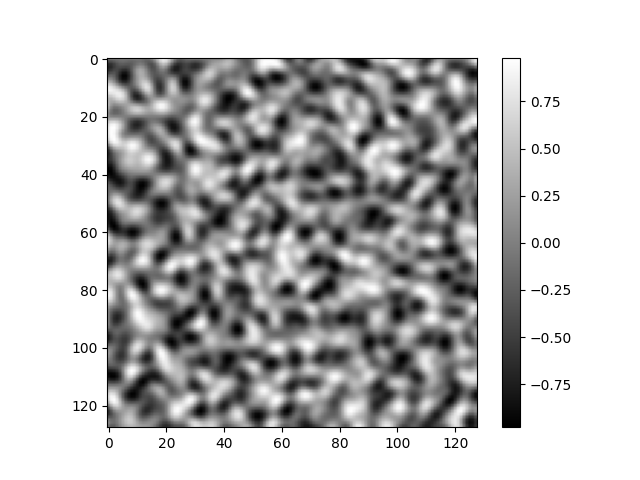

In [10]:
renderer = draw.NeuronRenderer(rng=np.random.default_rng(42))
noise = renderer._generate_simplex_noise((128, 128, 128), scale=10.0)
print(noise.shape)
plt.close('all')
plt.imshow(noise[0], cmap="gray")
plt.colorbar()
plt.show()

torch.Size([128, 128, 128])


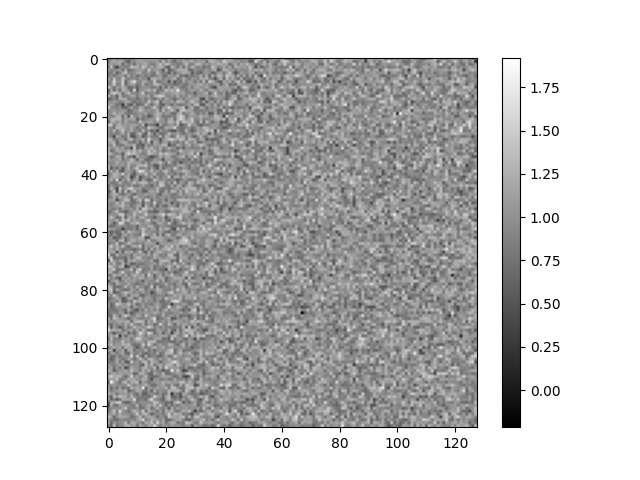

In [11]:
test_img = torch.ones((128, 128, 128))
renderer = draw.NeuronRenderer(rng=np.random.default_rng(42))
noise = renderer._add_gaussian_noise_tensor(test_img, foreground_mask=test_img.to(torch.bool), fg_std=0.239, bg_std=0.0)
print(noise.shape)
plt.close('all')
plt.imshow(noise[0], cmap="gray")
plt.colorbar()
plt.show()

Testing new stable noise generation methods...
Testing gaussian_convolution noise generation...
  ✓ gaussian_convolution: shape=torch.Size([128, 128, 128]), range=[-1.000, 1.000]
Testing fractal noise generation...


  ✓ fractal: shape=torch.Size([128, 128, 128]), range=[-1.000, 0.890]
Testing sparse_kernel noise generation...
  ✓ sparse_kernel: shape=torch.Size([128, 128, 128]), range=[-1.000, 0.892]
  ✓ sparse_kernel: shape=torch.Size([128, 128, 128]), range=[-1.000, 0.892]


/tmp/ipykernel_11272/698389533.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


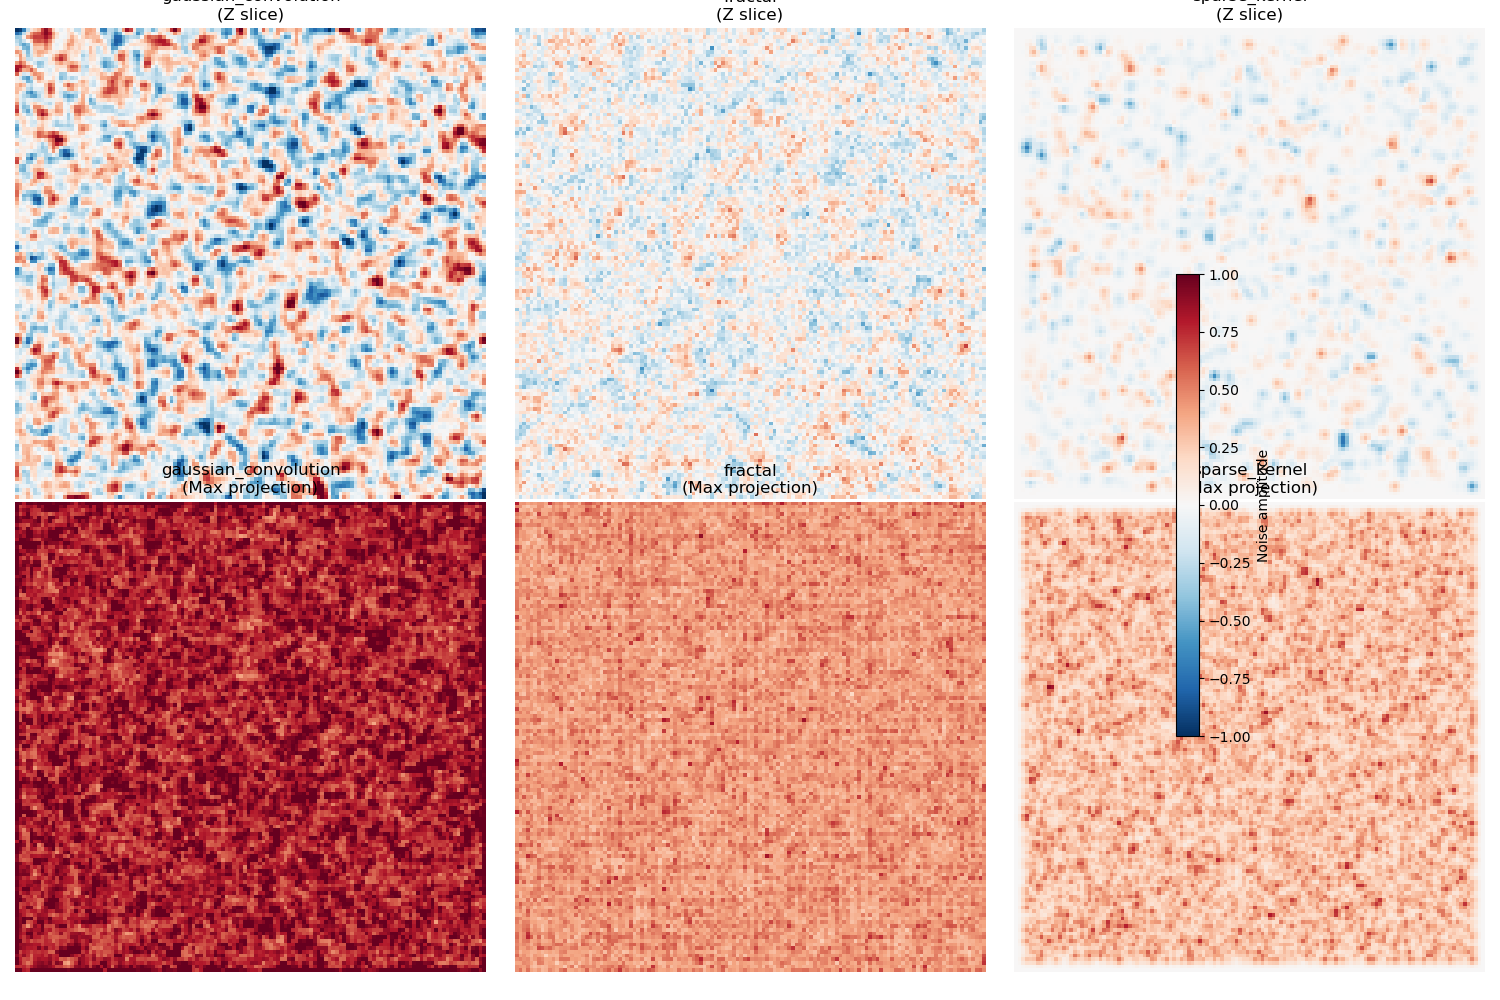


🎉 All new noise methods completed successfully!
These stable methods replace the problematic pyfastnoisesimd library.


In [14]:
# Test the new stable noise generation methods
print("Testing new stable noise generation methods...")

renderer = draw.NeuronRenderer(rng=np.random.default_rng(42))

# Test all three new noise methods
noise_methods = ['gaussian_convolution', 'fractal', 'sparse_kernel']
shape = (128, 128, 128)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, method in enumerate(noise_methods):
    print(f"Testing {method} noise generation...")
    try:
        # Generate noise using the new stable method
        noise = renderer._generate_spatially_correlated_noise(shape, scale=3.0, method=method)
        
        # Show XY slice (middle of Z dimension)
        z_slice = noise[shape[0]//2]
        axes[0, i].imshow(z_slice, cmap="RdBu_r", vmin=-1, vmax=1)
        axes[0, i].set_title(f'{method}\n(Z slice)')
        axes[0, i].axis('off')
        
        # Show max projection
        max_proj = noise.max(dim=0)[0]
        im = axes[1, i].imshow(max_proj, cmap="RdBu_r", vmin=-1, vmax=1)
        axes[1, i].set_title(f'{method}\n(Max projection)')
        axes[1, i].axis('off')
        
        print(f"  ✓ {method}: shape={noise.shape}, range=[{noise.min():.3f}, {noise.max():.3f}]")
        
    except Exception as e:
        print(f"  ✗ {method} failed: {e}")
        axes[0, i].text(0.5, 0.5, f"Failed:\n{method}", ha='center', va='center', transform=axes[0, i].transAxes)
        axes[1, i].text(0.5, 0.5, f"Failed:\n{method}", ha='center', va='center', transform=axes[1, i].transAxes)

# Add colorbar
plt.colorbar(im, ax=axes, shrink=0.6, label='Noise amplitude')
plt.tight_layout()
plt.show()

print("\n🎉 All new noise methods completed successfully!")
print("These stable methods replace the problematic pyfastnoisesimd library.")

The scalar complexity should affect the number of edges in a subtree within a range, and complexity=1.0 should trigger the full tree rather than a subtree. This will not require a fourth mode in get_subtrees, instead the _complexity_to_category should return 'full' which will cause the subtrees to be set to the whole swc_list and skip get_subtrees.
